In [63]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from xgboost import XGBRegressor

In [64]:
df = pd.read_csv("Sample - Superstore.csv",encoding='latin1')

In [65]:
df["Order Date"] = pd.to_datetime(df["Order Date"])

In [66]:
monthly_sales = (
    df.groupby(
        pd.Grouper(
            key="Order Date",
            freq="M"
        )
    )["Sales"]
    .sum()
    .reset_index()
)

monthly_sales.head()

/tmp/ipykernel_39777/178806343.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  pd.Grouper(


,Order Date,Sales
0,2014-01-31,14236.895
1,2014-02-28,4519.892
2,2014-03-31,55691.009
3,2014-04-30,28295.345
4,2014-05-31,23648.287


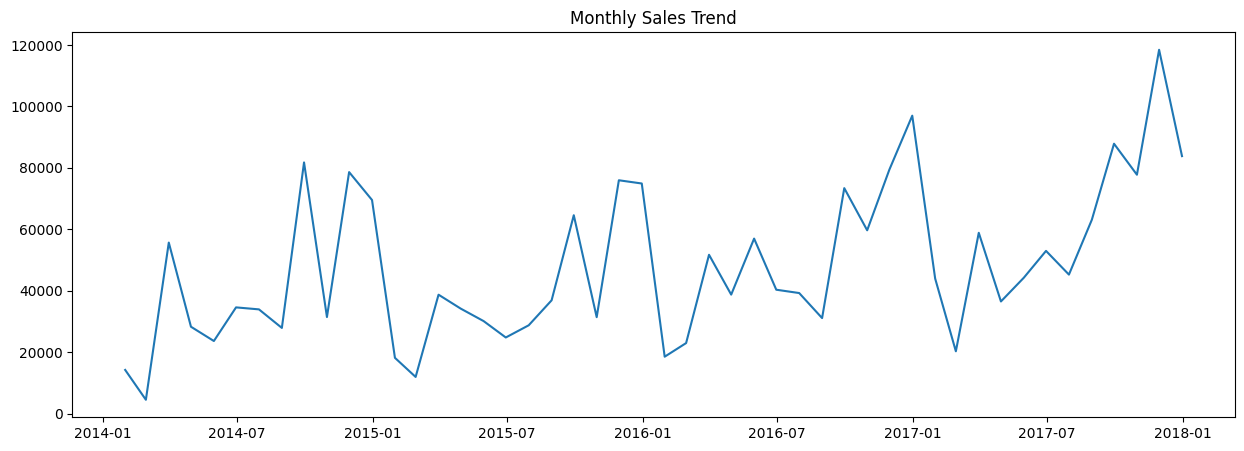

In [67]:
plt.figure(figsize=(15,5))

plt.plot(
    monthly_sales["Order Date"],
    monthly_sales["Sales"]
)

plt.title("Monthly Sales Trend")

plt.show()

In [68]:
monthly_sales["month"] = (
    monthly_sales["Order Date"].dt.month
)

monthly_sales["quarter"] = (
    monthly_sales["Order Date"].dt.quarter
)

monthly_sales["year"] = (
    monthly_sales["Order Date"].dt.year
)

In [69]:
monthly_sales["month_sin"] = np.sin(
    2 * np.pi * monthly_sales["month"] / 12
)

monthly_sales["month_cos"] = np.cos(
    2 * np.pi * monthly_sales["month"] / 12
)

In [70]:
monthly_sales["lag1"] = (
    monthly_sales["Sales"].shift(1)
)

monthly_sales["lag3"] = (
    monthly_sales["Sales"].shift(3)
)

monthly_sales["lag6"] = (
    monthly_sales["Sales"].shift(6)
)

In [71]:
monthly_sales["rolling3"] = (
    monthly_sales["Sales"]
    .rolling(3)
    .mean()
)

monthly_sales["rolling6"] = (
    monthly_sales["Sales"]
    .rolling(6)
    .mean()
)

In [72]:
monthly_sales.dropna(inplace=True)

monthly_sales.reset_index(
    drop=True,
    inplace=True
)

In [73]:
FEATURES = [
    "month",
    "quarter",
    "year",
    "month_sin",
    "month_cos",
    "lag1",
    "lag3",
    "lag6",
    "rolling3",
    "rolling6"
]

X = monthly_sales[FEATURES]

y = monthly_sales["Sales"]

In [74]:
split = int(
    len(monthly_sales)*0.8
)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

In [75]:
model = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.01,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

In [78]:
model.fit(
    X_train,
    y_train
)
predictions = model.predict(
    X_test
)

In [79]:
mae = mean_absolute_error(
    y_test,
    predictions
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        predictions
    )
)

r2 = r2_score(
    y_test,
    predictions
)

print("MAE :", round(mae,2))
print("RMSE:", round(rmse,2))
print("R²  :", round(r2,4))

MAE : 12561.66
RMSE: 14850.87
R²  : 0.6459


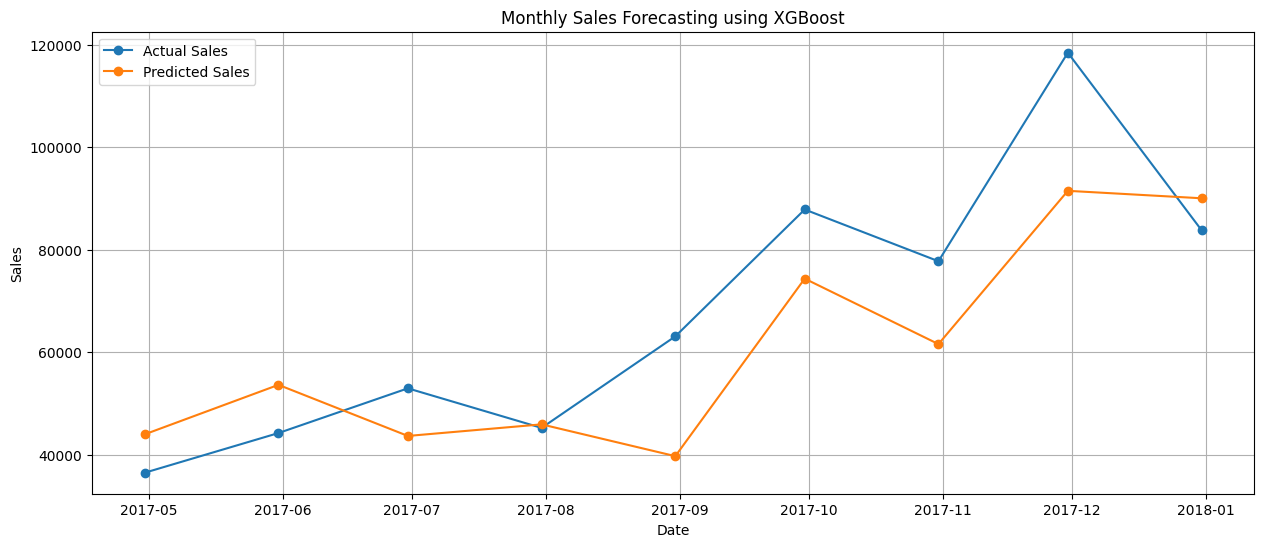

In [97]:
plt.figure(figsize=(15,6))

plt.plot(
    monthly_sales["Order Date"].iloc[split:],
    y_test,
    marker="o",
    label="Actual Sales"
)

plt.plot(
    monthly_sales["Order Date"].iloc[split:],
    predictions,
    marker="o",
    label="Predicted Sales"
)

plt.title("Monthly Sales Forecasting using XGBoost")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)

plt.savefig(
    "actual_vs_predicted.png",
    bbox_inches="tight"
)

plt.show()

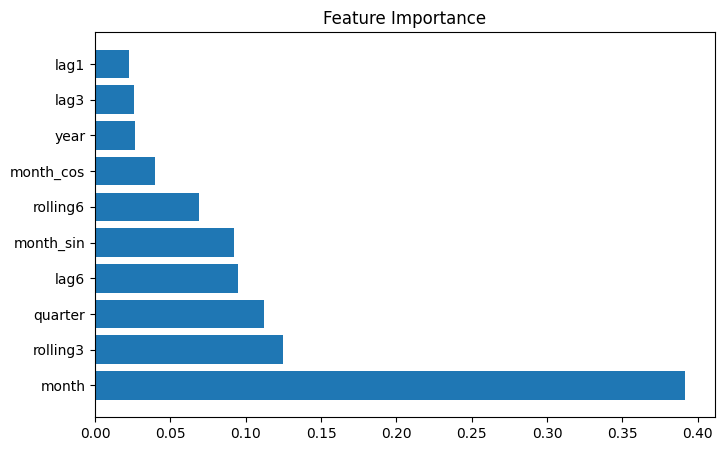

In [98]:
importance = pd.DataFrame({
    "Feature": FEATURES,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

plt.figure(figsize=(8,5))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.title("Feature Importance")

plt.show()

In [99]:
X_full = monthly_sales[FEATURES]

y_full = monthly_sales["Sales"]

final_model = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.01,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

final_model.fit(X_full, y_full)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.01, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=1000,
             n_jobs=None, num_parallel_tree=None, ...)

In [100]:
future_months = 12

last_date = monthly_sales["Order Date"].max()

future_dates = pd.date_range(
    start=last_date,
    periods=future_months + 1,
    freq="M"
)[1:]

future_dates

/tmp/ipykernel_39777/2796332904.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  future_dates = pd.date_range(


DatetimeIndex(['2018-01-31', '2018-02-28', '2018-03-31', '2018-04-30',
               '2018-05-31', '2018-06-30', '2018-07-31', '2018-08-31',
               '2018-09-30', '2018-10-31', '2018-11-30', '2018-12-31'],
              dtype='datetime64[ns]', freq='ME')

In [101]:
future_predictions = []

temp_df = monthly_sales.copy()

for date in future_dates:

    month = date.month
    quarter = date.quarter
    year = date.year

    month_sin = np.sin(
        2 * np.pi * month / 12
    )

    month_cos = np.cos(
        2 * np.pi * month / 12
    )

    lag1 = temp_df["Sales"].iloc[-1]
    lag3 = temp_df["Sales"].iloc[-3]
    lag6 = temp_df["Sales"].iloc[-6]

    rolling3 = temp_df["Sales"].tail(3).mean()
    rolling6 = temp_df["Sales"].tail(6).mean()

    future_row = pd.DataFrame({
        "month":[month],
        "quarter":[quarter],
        "year":[year],
        "month_sin":[month_sin],
        "month_cos":[month_cos],
        "lag1":[lag1],
        "lag3":[lag3],
        "lag6":[lag6],
        "rolling3":[rolling3],
        "rolling6":[rolling6]
    })

    pred = final_model.predict(
        future_row
    )[0]

    future_predictions.append(pred)

    temp_df = pd.concat([
        temp_df,
        pd.DataFrame({
            "Order Date":[date],
            "Sales":[pred]
        })
    ], ignore_index=True)

In [102]:
forecast_df = pd.DataFrame({
    "Date": future_dates,
    "Forecasted Sales": future_predictions
})

forecast_df

,Date,Forecasted Sales
0,2018-01-31,52028.714844
1,2018-02-28,52762.132812
2,2018-03-31,63885.738281
3,2018-04-30,58543.832031
4,2018-05-31,64669.195312
5,2018-06-30,65515.539062
6,2018-07-31,64987.296875
7,2018-08-31,68346.117188
8,2018-09-30,88393.562500
9,2018-10-31,82092.445312


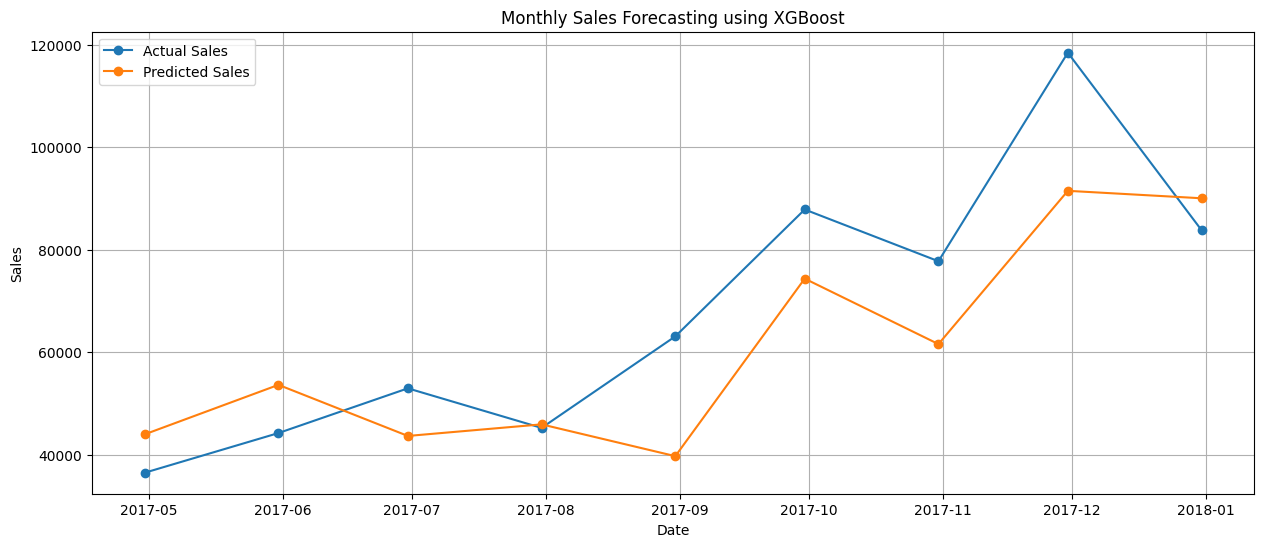

In [103]:
plt.figure(figsize=(15,6))

plt.plot(
    monthly_sales["Order Date"].iloc[split:],
    y_test,
    marker="o",
    label="Actual Sales"
)

plt.plot(
    monthly_sales["Order Date"].iloc[split:],
    predictions,
    marker="o",
    label="Predicted Sales"
)

plt.title("Monthly Sales Forecasting using XGBoost")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)

plt.savefig(
    "future_forecast.png",
    bbox_inches="tight"
)
plt.show()

In [104]:
forecast_df.to_csv(
    "future_sales_forecast.csv",
    index=False
)

forecast_df.head()


,Date,Forecasted Sales
0,2018-01-31,52028.714844
1,2018-02-28,52762.132812
2,2018-03-31,63885.738281
3,2018-04-30,58543.832031
4,2018-05-31,64669.195312


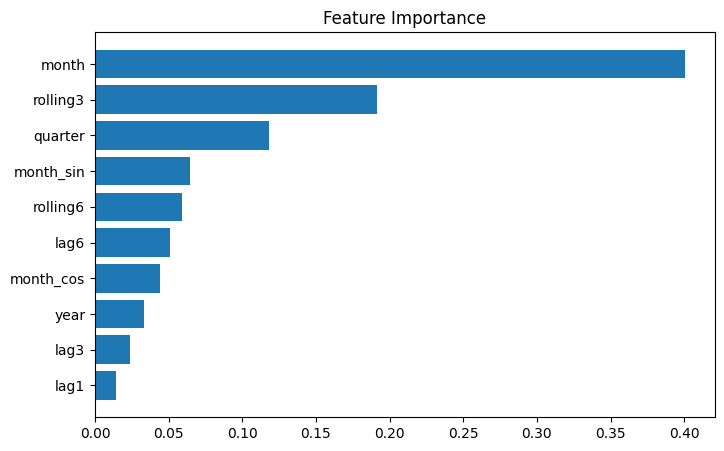

In [105]:
importance = pd.DataFrame({
    "Feature": FEATURES,
    "Importance": final_model.feature_importances_
})

importance = importance.sort_values(
    "Importance",
    ascending=True
)

plt.figure(figsize=(8,5))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.title(
    "Feature Importance"
)
plt.savefig(
    "feature_importance.png",
    bbox_inches="tight"
)
plt.show()

In [109]:
print("BUSINESS INSIGHTS")

print("- Sales show strong seasonal behavior.")
print("- Month was the most influential feature.")
print("- The model explains 64.6% of sales variation.")
print("- Forecasts can support inventory planning.")
print("- Forecasts can support staffing decisions.")

BUSINESS INSIGHTS
- Sales show strong seasonal behavior.
- Month was the most influential feature.
- The model explains 64.6% of sales variation.
- Forecasts can support inventory planning.
- Forecasts can support staffing decisions.


In [106]:
from google.colab import files

files.download("actual_vs_predicted.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [107]:
files.download("future_forecast.png")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [108]:
files.download("feature_importance.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>